In [1]:
# 노트북에서 상위 폴더의 모듈을 import하기 위한 경로 설정
import sys, os
sys.path.append(os.path.abspath(".."))   # notebooks/의 상위 = 프로젝트 루트

import torch
print("torch:", torch.__version__)
print("cuda:", torch.cuda.is_available())

torch: 2.6.0+cu124
cuda: True


In [2]:
from utils.data import get_dataloaders
from utils.train import fit
from utils.metrics import collect_predictions, print_metrics_report, get_confusion_matrix
from utils.visualize import (
    plot_learning_curve,
    plot_confusion_matrix,
    extract_features,
    plot_tsne,
)
from models.mlp import MLP

print("모든 모듈 import 성공")

모든 모듈 import 성공


In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

# 데이터 로딩 (train/val/test) — data_dir도 루트 기준으로
train_loader, val_loader, test_loader = get_dataloaders(
    batch_size=128,
    data_dir="../data"     # notebooks/의 상위 = 프로젝트 루트의 data/
)

# MLP 학습 (개발 단계니 15 epoch로 빠르게)
model = MLP()
history, best_epoch, test_result = fit(
    model, train_loader, val_loader, test_loader,
    epochs=15, device=device,
    save_path="../results/mlp_best.pth"   # 루트 기준
)

device: cuda
Epoch  1/15 | train_loss 0.2832 acc 0.9156 | val_loss 0.1502 acc 0.9545  <- best
Epoch  2/15 | train_loss 0.1079 acc 0.9673 | val_loss 0.1189 acc 0.9647  <- best
Epoch  3/15 | train_loss 0.0736 acc 0.9769 | val_loss 0.0899 acc 0.9732  <- best
Epoch  4/15 | train_loss 0.0527 acc 0.9834 | val_loss 0.0836 acc 0.9742  <- best
Epoch  5/15 | train_loss 0.0424 acc 0.9862 | val_loss 0.0935 acc 0.9723
Epoch  6/15 | train_loss 0.0321 acc 0.9897 | val_loss 0.0893 acc 0.9763
Epoch  7/15 | train_loss 0.0275 acc 0.9911 | val_loss 0.0994 acc 0.9718
Epoch  8/15 | train_loss 0.0254 acc 0.9914 | val_loss 0.0907 acc 0.9762
Epoch  9/15 | train_loss 0.0208 acc 0.9929 | val_loss 0.0902 acc 0.9765
Epoch 10/15 | train_loss 0.0176 acc 0.9940 | val_loss 0.1051 acc 0.9732
Epoch 11/15 | train_loss 0.0166 acc 0.9941 | val_loss 0.0974 acc 0.9763
Epoch 12/15 | train_loss 0.0144 acc 0.9949 | val_loss 0.1010 acc 0.9773
Epoch 13/15 | train_loss 0.0205 acc 0.9928 | val_loss 0.0897 acc 0.9778
Epoch 14/15 | t

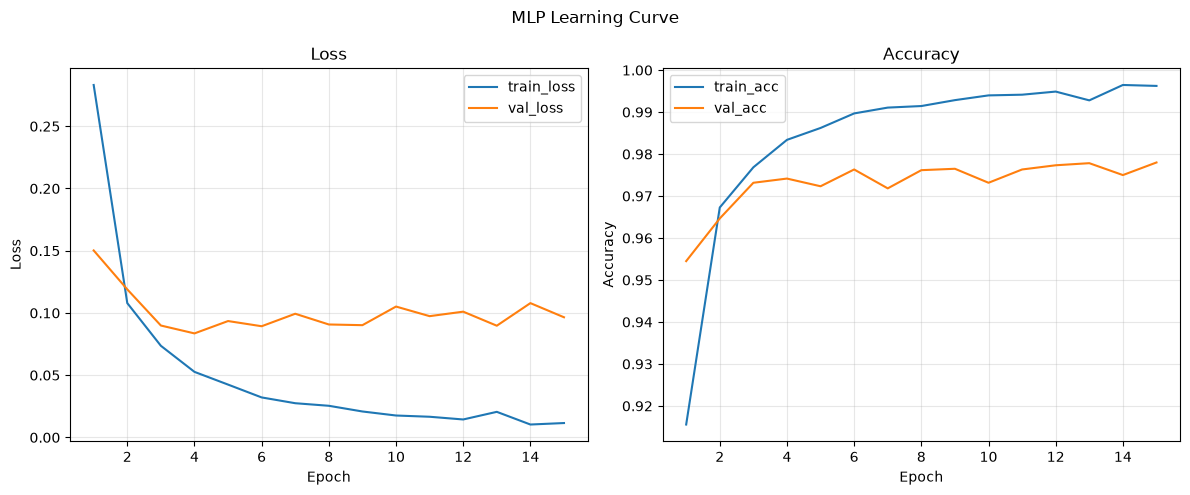

In [4]:
plot_learning_curve(history, title="MLP Learning Curve")

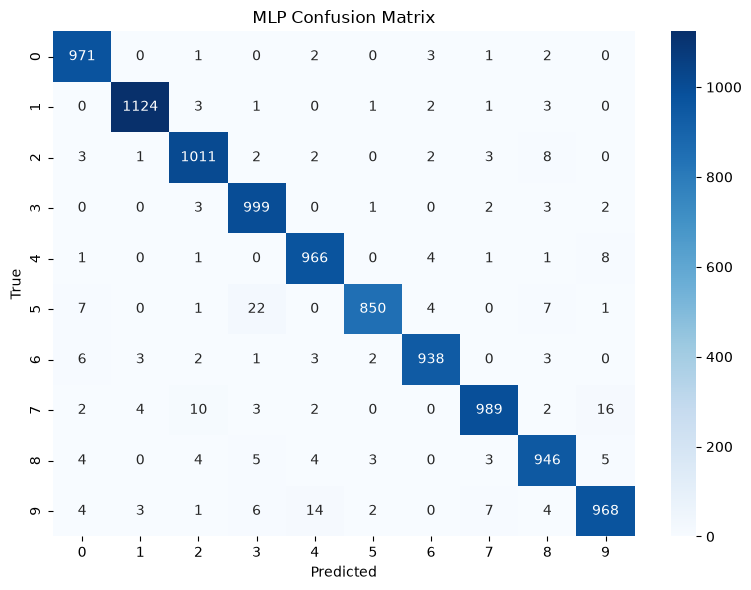

In [5]:
# best model로 test set 예측 수집
y_true, y_pred = collect_predictions(model, test_loader, device)

# confusion matrix heatmap (개수 버전)
plot_confusion_matrix(y_true, y_pred, title="MLP Confusion Matrix")

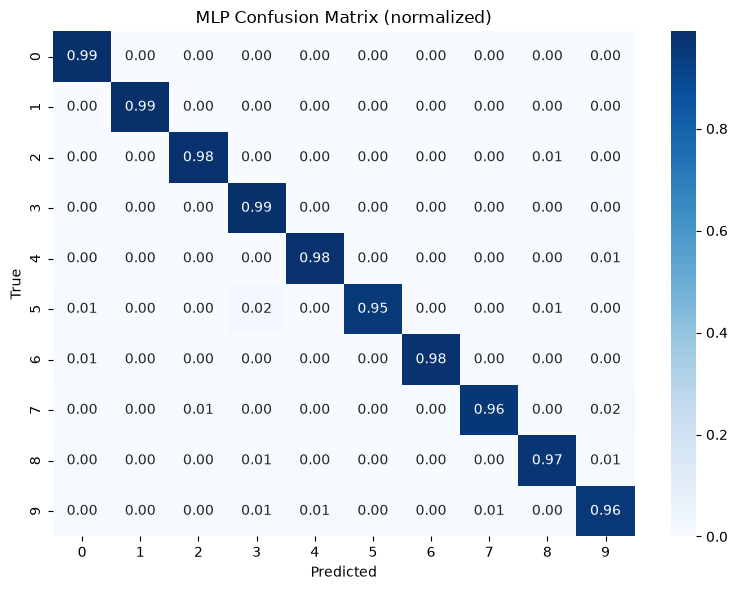

In [6]:
plot_confusion_matrix(y_true, y_pred, title="MLP Confusion Matrix (normalized)", normalize=True)

feature shape: (2000, 128)


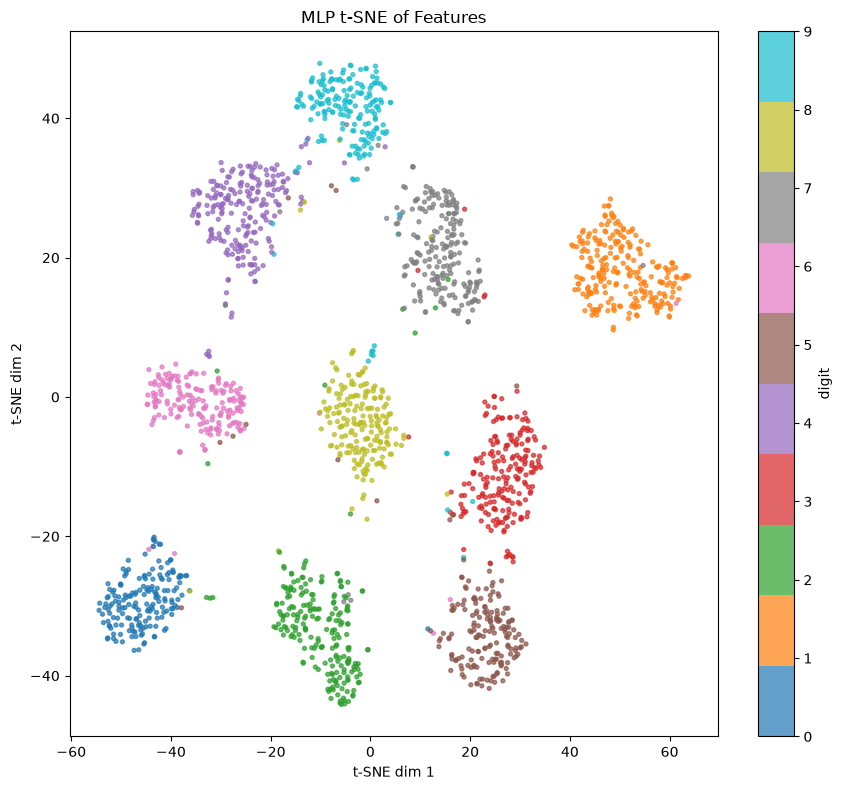

In [7]:
# penultimate feature 추출 (t-SNE는 느리니 2000개만)
features, labels = extract_features(model, test_loader, device, max_samples=2000)
print("feature shape:", features.shape)   # (2000, 128)

# t-SNE로 2D 투영해서 그리기
plot_tsne(features, labels, title="MLP t-SNE of Features")

In [8]:
from models.cnn import CNN

# CNN 학습 (MLP와 동일 조건: 15 epoch, 같은 데이터)
cnn_model = CNN()
cnn_history, cnn_best_epoch, cnn_test_result = fit(
    cnn_model, train_loader, val_loader, test_loader,
    epochs=15, device=device,
    save_path="../results/cnn_best.pth"
)

Epoch  1/15 | train_loss 0.1743 acc 0.9471 | val_loss 0.0675 acc 0.9795  <- best
Epoch  2/15 | train_loss 0.0504 acc 0.9849 | val_loss 0.0516 acc 0.9855  <- best
Epoch  3/15 | train_loss 0.0343 acc 0.9895 | val_loss 0.0380 acc 0.9870  <- best
Epoch  4/15 | train_loss 0.0233 acc 0.9929 | val_loss 0.0404 acc 0.9877
Epoch  5/15 | train_loss 0.0188 acc 0.9940 | val_loss 0.0478 acc 0.9860
Epoch  6/15 | train_loss 0.0180 acc 0.9944 | val_loss 0.0362 acc 0.9898  <- best
Epoch  7/15 | train_loss 0.0117 acc 0.9964 | val_loss 0.0417 acc 0.9887
Epoch  8/15 | train_loss 0.0096 acc 0.9968 | val_loss 0.0426 acc 0.9878
Epoch  9/15 | train_loss 0.0091 acc 0.9971 | val_loss 0.0453 acc 0.9883
Epoch 10/15 | train_loss 0.0064 acc 0.9978 | val_loss 0.0522 acc 0.9872
Epoch 11/15 | train_loss 0.0087 acc 0.9969 | val_loss 0.0538 acc 0.9868
Epoch 12/15 | train_loss 0.0069 acc 0.9977 | val_loss 0.0670 acc 0.9853
Epoch 13/15 | train_loss 0.0055 acc 0.9983 | val_loss 0.0511 acc 0.9887
Epoch 14/15 | train_loss 0.0

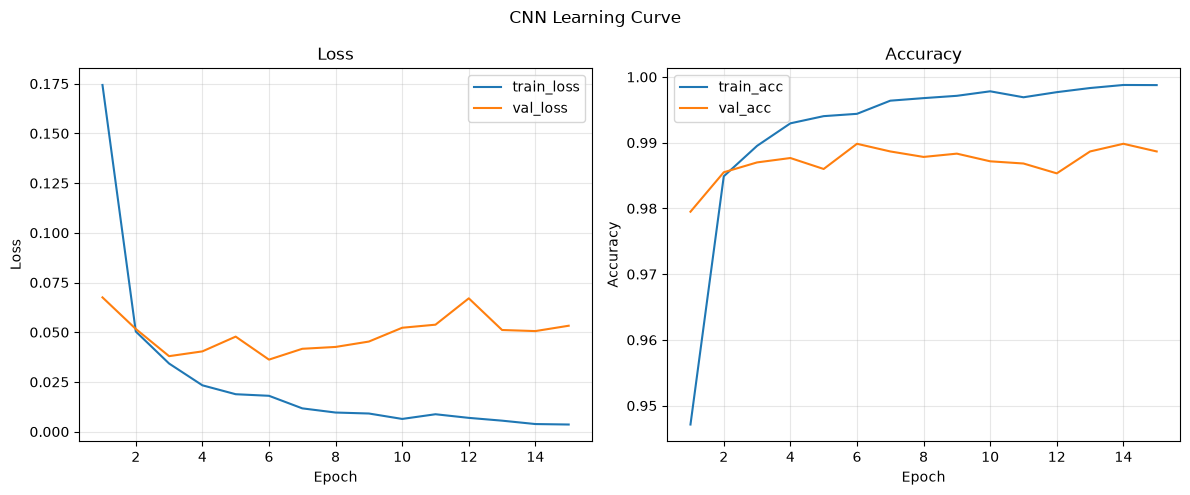

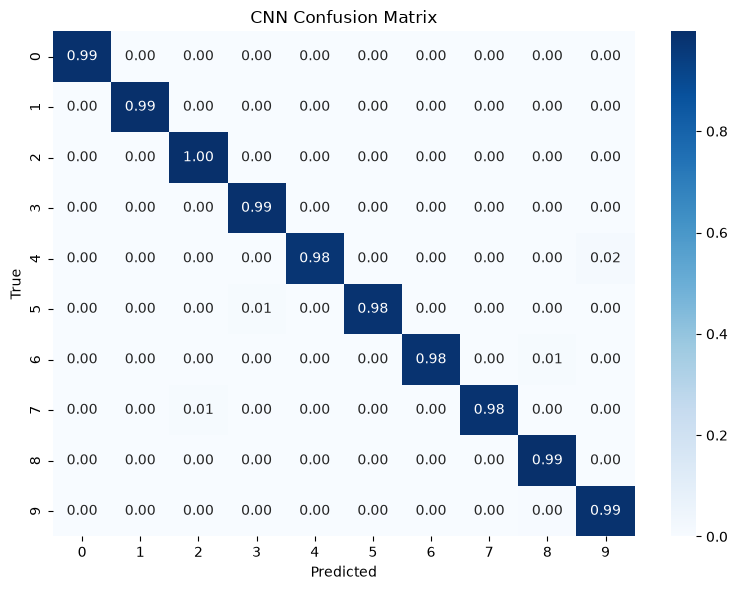

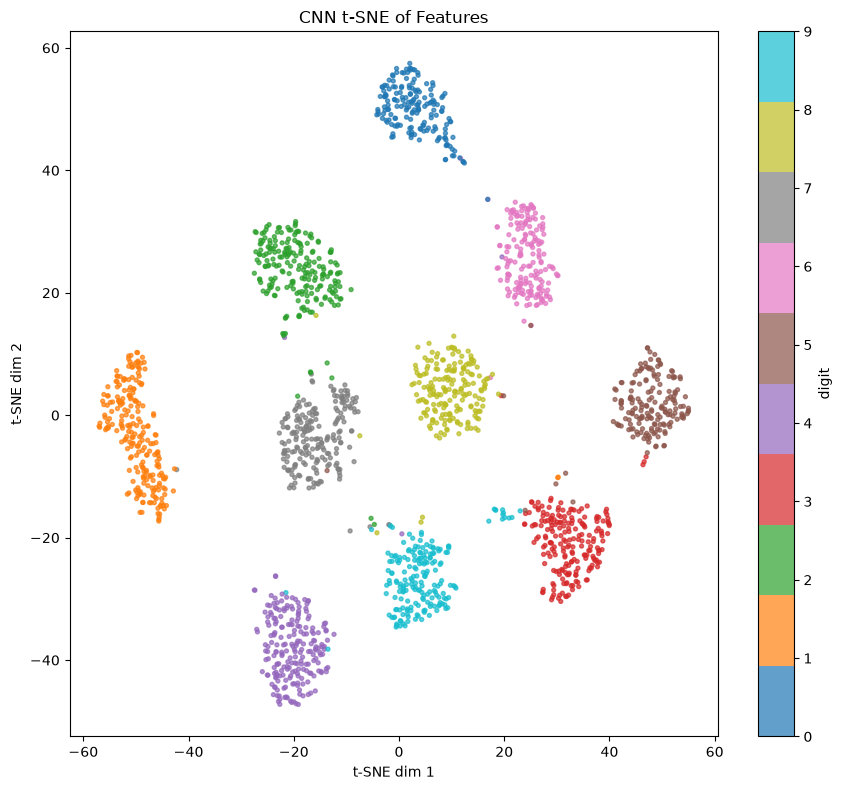

In [9]:
# 1) CNN learning curve
plot_learning_curve(cnn_history, title="CNN Learning Curve")

# 2) CNN confusion matrix
cnn_y_true, cnn_y_pred = collect_predictions(cnn_model, test_loader, device)
plot_confusion_matrix(cnn_y_true, cnn_y_pred, title="CNN Confusion Matrix", normalize=True)

# 3) CNN t-SNE
cnn_features, cnn_labels = extract_features(cnn_model, test_loader, device, max_samples=2000)
plot_tsne(cnn_features, cnn_labels, title="CNN t-SNE of Features")

In [10]:
import time
from models.rnn import RNN

# RNN 학습 (동일 조건: 15 epoch) + 시간 측정
rnn_model = RNN()

start = time.time()
rnn_history, rnn_best_epoch, rnn_test_result = fit(
    rnn_model, train_loader, val_loader, test_loader,
    epochs=15, device=device,
    save_path="../results/rnn_best.pth"
)
rnn_time = time.time() - start
print(f"\n>> RNN 총 학습 시간: {rnn_time:.1f}초 ({rnn_time/15:.1f}초/epoch)")

Epoch  1/15 | train_loss 0.4514 acc 0.8526 | val_loss 0.1364 acc 0.9613  <- best
Epoch  2/15 | train_loss 0.0983 acc 0.9712 | val_loss 0.0905 acc 0.9740  <- best
Epoch  3/15 | train_loss 0.0688 acc 0.9794 | val_loss 0.0737 acc 0.9802  <- best
Epoch  4/15 | train_loss 0.0507 acc 0.9845 | val_loss 0.0585 acc 0.9830  <- best
Epoch  5/15 | train_loss 0.0402 acc 0.9874 | val_loss 0.0634 acc 0.9825
Epoch  6/15 | train_loss 0.0346 acc 0.9897 | val_loss 0.0480 acc 0.9870  <- best
Epoch  7/15 | train_loss 0.0303 acc 0.9907 | val_loss 0.0546 acc 0.9845
Epoch  8/15 | train_loss 0.0271 acc 0.9916 | val_loss 0.0501 acc 0.9867
Epoch  9/15 | train_loss 0.0246 acc 0.9923 | val_loss 0.0546 acc 0.9845
Epoch 10/15 | train_loss 0.0210 acc 0.9933 | val_loss 0.0419 acc 0.9890  <- best
Epoch 11/15 | train_loss 0.0188 acc 0.9941 | val_loss 0.0402 acc 0.9863  <- best
Epoch 12/15 | train_loss 0.0184 acc 0.9942 | val_loss 0.0391 acc 0.9888  <- best
Epoch 13/15 | train_loss 0.0135 acc 0.9957 | val_loss 0.0426 acc

In [11]:
import time

# MLP 시간 측정
mlp_m = MLP()
t0 = time.time()
fit(mlp_m, train_loader, val_loader, test_loader, epochs=15, device=device, save_path="../results/mlp_best.pth")
mlp_time = time.time() - t0

# CNN 시간 측정
cnn_m = CNN()
t0 = time.time()
fit(cnn_m, train_loader, val_loader, test_loader, epochs=15, device=device, save_path="../results/cnn_best.pth")
cnn_time = time.time() - t0

print(f"\nMLP: {mlp_time:.1f}초 | CNN: {cnn_time:.1f}초 | RNN: {rnn_time:.1f}초")

Epoch  1/15 | train_loss 0.2845 acc 0.9179 | val_loss 0.1637 acc 0.9523  <- best
Epoch  2/15 | train_loss 0.1114 acc 0.9660 | val_loss 0.1166 acc 0.9643  <- best
Epoch  3/15 | train_loss 0.0735 acc 0.9766 | val_loss 0.1032 acc 0.9682  <- best
Epoch  4/15 | train_loss 0.0540 acc 0.9827 | val_loss 0.0903 acc 0.9730  <- best
Epoch  5/15 | train_loss 0.0403 acc 0.9871 | val_loss 0.0849 acc 0.9755  <- best
Epoch  6/15 | train_loss 0.0332 acc 0.9895 | val_loss 0.0931 acc 0.9737
Epoch  7/15 | train_loss 0.0291 acc 0.9904 | val_loss 0.0864 acc 0.9743
Epoch  8/15 | train_loss 0.0223 acc 0.9927 | val_loss 0.0843 acc 0.9758  <- best
Epoch  9/15 | train_loss 0.0176 acc 0.9944 | val_loss 0.1148 acc 0.9713
Epoch 10/15 | train_loss 0.0223 acc 0.9920 | val_loss 0.1013 acc 0.9730
Epoch 11/15 | train_loss 0.0159 acc 0.9944 | val_loss 0.0988 acc 0.9765
Epoch 12/15 | train_loss 0.0111 acc 0.9966 | val_loss 0.0821 acc 0.9788  <- best
Epoch 13/15 | train_loss 0.0128 acc 0.9955 | val_loss 0.1581 acc 0.9652
E

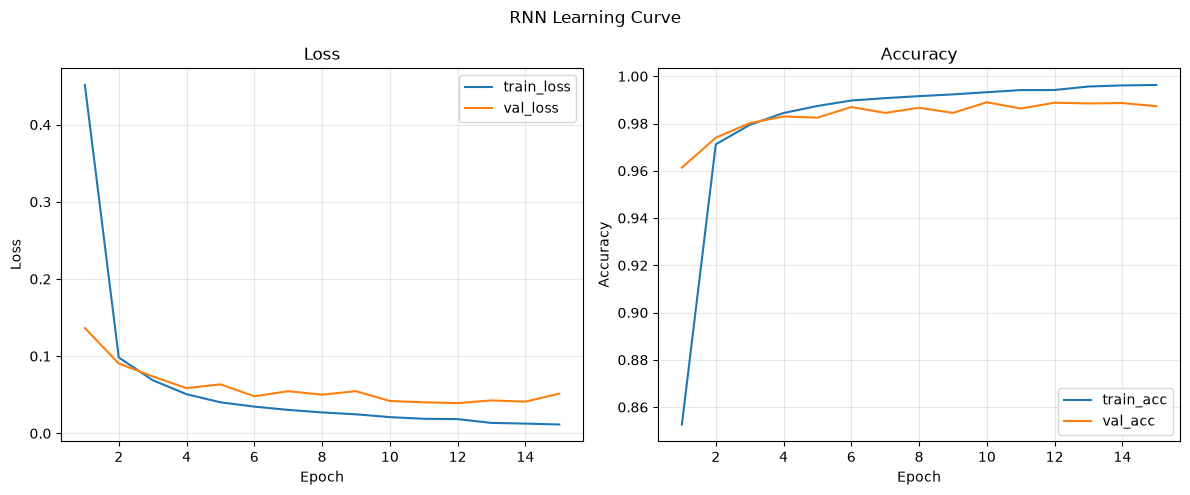

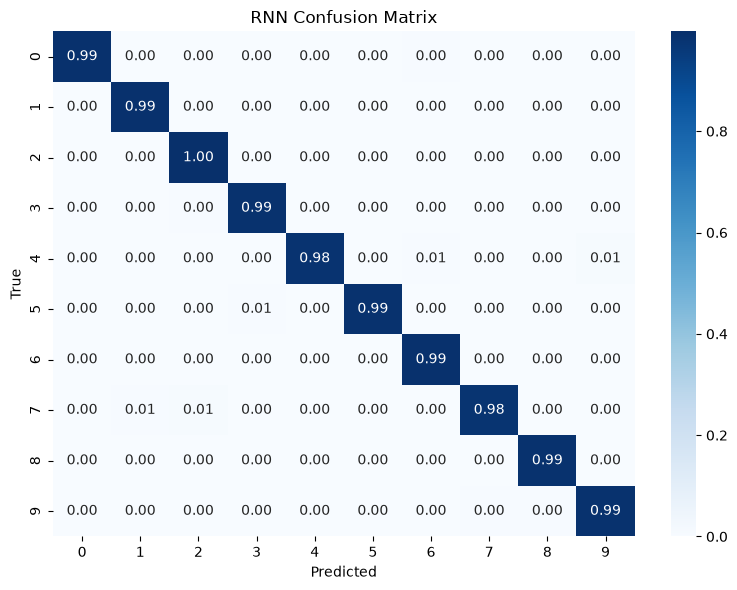

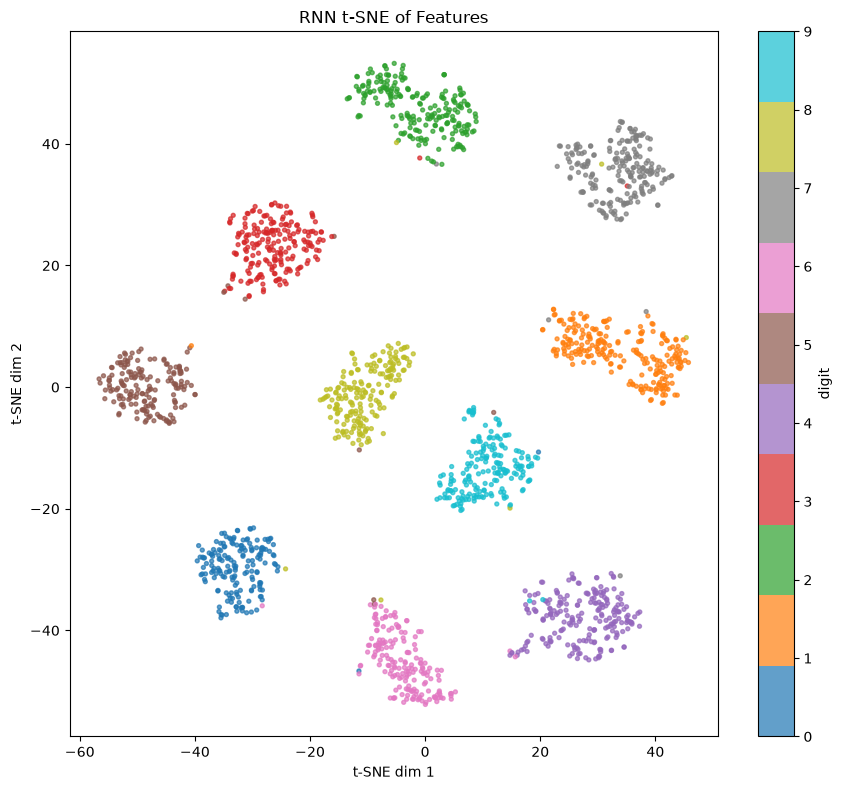

In [12]:
# RNN 시각화 3종
plot_learning_curve(rnn_history, title="RNN Learning Curve")

rnn_y_true, rnn_y_pred = collect_predictions(rnn_model, test_loader, device)
plot_confusion_matrix(rnn_y_true, rnn_y_pred, title="RNN Confusion Matrix", normalize=True)

rnn_features, rnn_labels = extract_features(rnn_model, test_loader, device, max_samples=2000)
plot_tsne(rnn_features, rnn_labels, title="RNN t-SNE of Features")